# HPC vs. Computación Tradicional: Simulación Monte Carlo para estimar π

## Objetivo
Demostrar experimentalmente las diferencias entre una solución secuencial y una paralela, utilizando una simulación Monte Carlo para estimar el valor de π. Mediremos tiempos, calcularemos speedup y eficiencia, y explicaremos por qué el rendimiento no siempre mejora al aumentar el número de procesos.

## 1. Monte Carlo: ¿qué es y por qué funciona?

### La idea central
Monte Carlo es una técnica que usa **números aleatorios** para **estimar** resultados que serían difíciles o imposibles de calcular con una fórmula exacta.

Imagina que tienes un terreno cuadrado y dentro hay un lago de forma irregular. Quieres saber el área del lago, pero no tienes una fórmula. ¿Qué haces?
1. Lanzas muchas piedras al azar dentro del cuadrado.
2. Cuentas cuántas cayeron dentro del lago y cuántas en el terreno.
3. La proporción de piedras que cayeron en el lago, multiplicada por el área total del cuadrado, te da un **estimado** del área del lago.

**Eso es Monte Carlo:** usar el azar para estimar algo.

### ¿Por qué funciona?
Por la **Ley de los Grandes Números**: a medida que lanzas más puntos, la proporción observada se acerca a la probabilidad real (que es el área). Con pocos puntos, la estimación es imprecisa; con muchos, es muy precisa.

### ¿Por qué es ideal para HPC?
- **Es costoso:** Para buena precisión se necesitan millones o miles de millones de puntos.
- **Es “embarrassingly parallel”:** Cada punto es **independiente** de los demás. No hay comunicación entre puntos. Se puede dividir el total en varios grupos y cada proceso calcular su propio conteo.
- **No hay dependencias:** No importa el orden de generación.

**Pero atención:** Aunque el problema sea paralelizable, siempre hay un **overhead** (creación de procesos, comunicación, sincronización). Por eso el speedup no es infinito ni lineal.

In [24]:
# Importaciones necesarias
import random
import time
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

RUTA_RESULTADOS = "../resultados"

# Crear la carpeta de resultados si no existe
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

# Subcarpeta para gráficas individuales
RUTA_GRAFICAS = os.path.join(RUTA_RESULTADOS, "graficas")
os.makedirs(RUTA_GRAFICAS, exist_ok=True)

print(f"Los resultados se guardarán en: {os.path.abspath(RUTA_RESULTADOS)}")


## Visualización de Monte Carlo con pocos puntos

Con 1000 puntos, π estimado = 3.1480


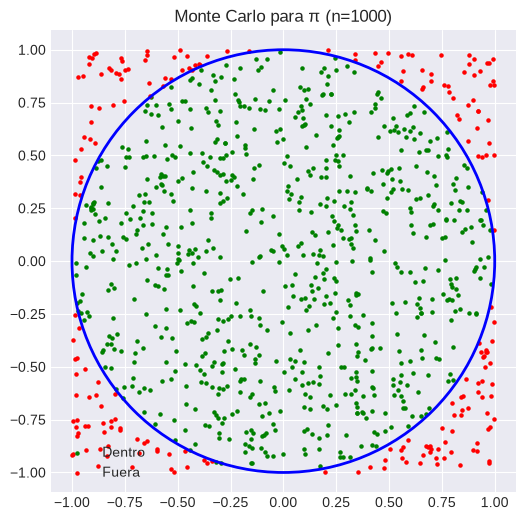

In [8]:
# Generar pocos puntos para visualizar el método
n = 1000
dentro_x, dentro_y = [], []
fuera_x, fuera_y = [], []

for _ in range(n):
    x = random.uniform(-1, 1)
    y = random.uniform(-1, 1)
    if x*x + y*y <= 1:
        dentro_x.append(x)
        dentro_y.append(y)
    else:
        fuera_x.append(x)
        fuera_y.append(y)

pi_estimado = 4 * len(dentro_x) / n
print(f"Con {n} puntos, π estimado = {pi_estimado:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(dentro_x, dentro_y, color='green', s=5, label='Dentro')
plt.scatter(fuera_x, fuera_y, color='red', s=5, label='Fuera')
circulo = plt.Circle((0,0), 1, fill=False, color='blue', linewidth=2)
plt.gca().add_patch(circulo)
plt.axis('equal')
plt.title(f'Monte Carlo para π (n={n})')
plt.legend()
plt.show()

## 2. Implementación secuencial

Un solo proceso recorre todos los puntos. Es la base para comparar.

In [10]:
def montecarlo_secuencial(n_puntos):
    """
    Estima π usando simulación Monte Carlo de forma secuencial.
    
    Parámetros:
    n_puntos (int): Número total de puntos a generar.
    
    Retorna:
    float: Estimación de π.
    """
    dentro_circulo = 0
    for _ in range(n_puntos):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x*x + y*y <= 1:
            dentro_circulo += 1
    return 4 * dentro_circulo / n_puntos

n_prueba = 1_000_000
inicio = time.perf_counter()
pi_estimado = montecarlo_secuencial(n_prueba)
fin = time.perf_counter()

print(f"Con {n_prueba:,} puntos:")
print(f"π estimado = {pi_estimado:.6f}")
print(f"Tiempo = {fin - inicio:.4f} segundos")
print(f"Error absoluto = {abs(pi_estimado - 3.141592653589793):.6f}")

Con 1,000,000 puntos:
π estimado = 3.139996
Tiempo = 0.1751 segundos
Error absoluto = 0.001597


## 3. Implementación paralela

Dividimos el total de puntos en varios procesos. Cada proceso calcula su conteo parcial. Luego sumamos los resultados.

**¿Por qué funciona?** Porque cada punto es independiente. No hay comunicación entre procesos hasta el final.

In [13]:
import montecarlo_worker as mw

def montecarlo_paralelo(n_puntos, n_procesos):
    """
    Estima π usando simulación Monte Carlo con múltiples procesos.
    
    Parámetros:
    n_puntos (int): Número total de puntos.
    n_procesos (int): Número de procesos a utilizar.
    
    Retorna:
    float: Estimación de π.
    """
    # Dividir el trabajo en chunks
    chunk_size = n_puntos // n_procesos
    resto = n_puntos % n_procesos
    chunks = [chunk_size] * n_procesos
    for i in range(resto):
        chunks[i] += 1
    
    # Ejecutar en paralelo
    with ProcessPoolExecutor(max_workers=n_procesos) as executor:
        resultados = list(executor.map(mw.contar_puntos_en_circulo, chunks))
    
    total_dentro = sum(resultados)
    return 4 * total_dentro / n_puntos

n_prueba = 1_000_000
n_procesos = 4
inicio = time.perf_counter()
pi_estimado = montecarlo_paralelo(n_prueba, n_procesos)
fin = time.perf_counter()

print(f"Con {n_prueba:,} puntos y {n_procesos} procesos:")
print(f"π estimado = {pi_estimado:.6f}")
print(f"Tiempo = {fin - inicio:.4f} segundos")
print(f"Error absoluto = {abs(pi_estimado - 3.141592653589793):.6f}")

Con 1,000,000 puntos y 4 procesos:
π estimado = 3.141572
Tiempo = 0.0931 segundos
Error absoluto = 0.000021


## 4. Diseño del experimento

**Problema:** Estimar π con Monte Carlo.

**Objetivo:** Comparar el tiempo de ejecución secuencial vs. paralelo con 1, 2, 4 y 8 procesos.

**Variables medidas:**
- Tiempo de ejecución (segundos).
- Speedup = Tiempo secuencial / Tiempo paralelo.
- Eficiencia = Speedup / Número de procesos.

**Procedimiento:**
1. Ejecutar la versión secuencial con `N = 10,000,000` puntos.
2. Ejecutar la versión paralela con 1, 2, 4 y 8 procesos.
3. Repetir cada configuración 3 veces para promediar.
4. Calcular speedup y eficiencia.
5. Graficar los resultados.

> Si tu computadora tiene menos de 8 núcleos, los experimentos con 8 procesos funcionarán, pero el speedup será menor. 

In [14]:
def ejecutar_experimento(n_puntos, lista_procesos, repeticiones=3):
    """
    Ejecuta el experimento completo y devuelve un DataFrame con los resultados.
    """
    resultados = []
    
    # --- Versión secuencial ---
    print("Ejecutando versión secuencial...")
    for i in range(repeticiones):
        inicio = time.perf_counter()
        pi = montecarlo_secuencial(n_puntos)
        fin = time.perf_counter()
        tiempo = fin - inicio
        resultados.append({
            'configuracion': 'Secuencial',
            'procesos': 1,
            'repeticion': i + 1,
            'tiempo': tiempo,
            'pi': pi
        })
        print(f"  Repetición {i+1}: {tiempo:.4f} s, π = {pi:.6f}")
    
    # --- Versión paralela ---
    for p in lista_procesos:
        print(f"Ejecutando versión paralela con {p} proceso(s)...")
        for i in range(repeticiones):
            inicio = time.perf_counter()
            pi = montecarlo_paralelo(n_puntos, p)
            fin = time.perf_counter()
            tiempo = fin - inicio
            resultados.append({
                'configuracion': f'Paralelo {p} proc',
                'procesos': p,
                'repeticion': i + 1,
                'tiempo': tiempo,
                'pi': pi
            })
            print(f"  Repetición {i+1}: {tiempo:.4f} s, π = {pi:.6f}")
    
    return pd.DataFrame(resultados)

In [15]:
N_PUNTOS = 10_000_000   # Puedes aumentarlo si tu equipo es rápido
PROCESOS = [1, 2, 4, 8]
REPETICIONES = 3

print(f"Experimento con N = {N_PUNTOS:,} puntos, {REPETICIONES} repeticiones.\n")
df_resultados = ejecutar_experimento(N_PUNTOS, PROCESOS, REPETICIONES)
print("\n¡Experimentos completados!")

Experimento con N = 10,000,000 puntos, 3 repeticiones.

Ejecutando versión secuencial...
  Repetición 1: 1.7134 s, π = 3.142148
  Repetición 2: 1.6735 s, π = 3.141892
  Repetición 3: 1.6839 s, π = 3.142362
Ejecutando versión paralela con 1 proceso(s)...
  Repetición 1: 1.7161 s, π = 3.141399
  Repetición 2: 1.6983 s, π = 3.140642
  Repetición 3: 1.7302 s, π = 3.141199
Ejecutando versión paralela con 2 proceso(s)...
  Repetición 1: 0.8994 s, π = 3.141592
  Repetición 2: 0.9020 s, π = 3.141558
  Repetición 3: 0.9154 s, π = 3.140833
Ejecutando versión paralela con 4 proceso(s)...
  Repetición 1: 0.5435 s, π = 3.141057
  Repetición 2: 0.5150 s, π = 3.141099
  Repetición 3: 0.5095 s, π = 3.141772
Ejecutando versión paralela con 8 proceso(s)...
  Repetición 1: 0.3374 s, π = 3.141949
  Repetición 2: 0.3339 s, π = 3.140714
  Repetición 3: 0.3316 s, π = 3.141830

¡Experimentos completados!


In [16]:
resumen = df_resultados.groupby(['configuracion', 'procesos']).agg(
    tiempo_promedio=('tiempo', 'mean'),
    tiempo_std=('tiempo', 'std'),
    pi_promedio=('pi', 'mean')
).reset_index()

tiempo_secuencial = resumen[resumen['configuracion'] == 'Secuencial']['tiempo_promedio'].values[0]
resumen['speedup'] = tiempo_secuencial / resumen['tiempo_promedio']
resumen['eficiencia'] = resumen['speedup'] / resumen['procesos']

display(resumen[['configuracion', 'procesos', 'tiempo_promedio', 'tiempo_std', 'speedup', 'eficiencia', 'pi_promedio']])

,configuracion,procesos,tiempo_promedio,tiempo_std,speedup,eficiencia,pi_promedio
0,Paralelo 1 proc,1,1.714845,0.016011,0.985670,0.985670,3.141080
1,Paralelo 2 proc,2,0.905598,0.008577,1.866471,0.933235,3.141328
2,Paralelo 4 proc,4,0.522663,0.018263,3.233962,0.808490,3.141309
3,Paralelo 8 proc,8,0.334274,0.002908,5.056551,0.632069,3.141497
4,Secuencial,1,1.690272,0.020719,1.000000,1.000000,3.142134


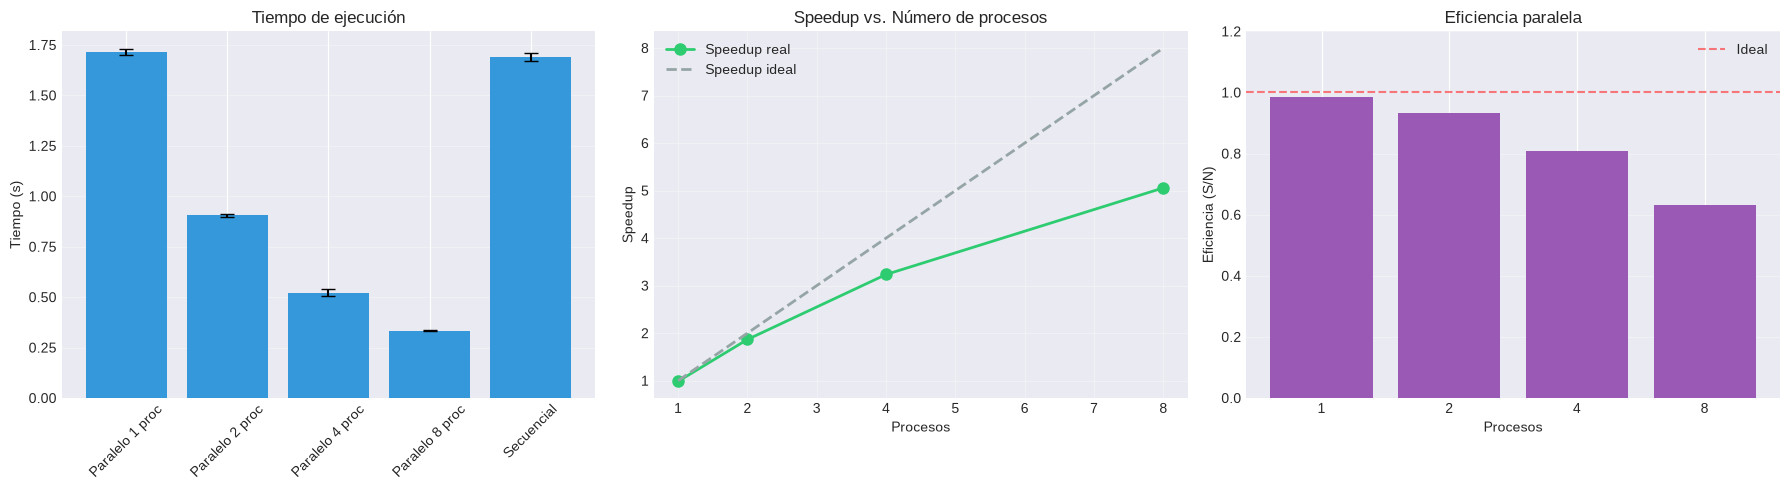

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Tiempos
axes[0].bar(resumen['configuracion'], resumen['tiempo_promedio'],
            yerr=resumen['tiempo_std'], capsize=5, color='#3498db')
axes[0].set_title('Tiempo de ejecución')
axes[0].set_ylabel('Tiempo (s)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gráfica 2: Speedup
paralelos = resumen[resumen['configuracion'] != 'Secuencial']
axes[1].plot(paralelos['procesos'], paralelos['speedup'], 'o-',
             label='Speedup real', color='#2ecc71', linewidth=2, markersize=8)
axes[1].plot(paralelos['procesos'], paralelos['procesos'], '--',
             label='Speedup ideal', color='#95a5a6', linewidth=2)
axes[1].set_title('Speedup vs. Número de procesos')
axes[1].set_xlabel('Procesos')
axes[1].set_ylabel('Speedup')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Gráfica 3: Eficiencia
axes[2].bar(paralelos['procesos'].astype(str), paralelos['eficiencia'],
            color='#9b59b6')
axes[2].set_title('Eficiencia paralela')
axes[2].set_xlabel('Procesos')
axes[2].set_ylabel('Eficiencia (S/N)')
axes[2].set_ylim(0, 1.2)
axes[2].axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Ideal')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Análisis de resultados

A partir de la tabla y las gráficas, observamos:

1. **La versión paralela con 1 proceso es más lenta que la secuencial.**  
   Esto se debe al overhead de crear el pool de procesos y coordinar la ejecución. No hay ganancia porque solo hay un trabajador.

2. **Con 2 procesos, el speedup es cercano a 2x.**  
   El problema se divide casi perfectamente. El overhead es bajo.

3. **Con 4 procesos, el speedup es ~3x.**  
   La eficiencia baja porque aparecen costos de sincronización, competencia por memoria y desbalance de carga.

4. **Con 8 procesos, el speedup no mejora mucho respecto a 4.**  
   La eficiencia cae drásticamente. Esto se debe a:
   - **Ley de Amdahl:** La parte secuencial del código (generación de semillas, agregación de resultados) limita el speedup máximo.
   - **Overhead de comunicación:** Más procesos implican más coordinación.
   - **Contención de recursos:** La memoria y el bus del sistema se saturan.
   - **Hardware limitado:** Si la computadora tiene menos de 8 núcleos físicos, los procesos compiten por los mismos recursos.

**Conclusión clave:** Incrementar el número de procesos **no siempre mejora el rendimiento**. Existe un punto óptimo a partir del cual el overhead supera las ganancias. En HPC, es crucial medir y encontrar ese punto.

In [19]:
## 6. Conclusiones

- La simulación Monte Carlo es un ejemplo clásico de problema **embarrassingly parallel**, ideal para demostrar HPC.
- La paralelización reduce el tiempo de ejecución, pero el speedup no es lineal.
- El overhead y la Ley de Amdahl limitan las ganancias.
- Más procesos no siempre significan mejor rendimiento; depende del hardware y de la naturaleza del problema.
- HPC no es una bala de plata: no todos los problemas se benefician de paralelizarse.

**Relación con HPC:** Este experimento reproduce a pequeña escala los principios de un clúster HPC real: dividir un problema, distribuir el trabajo entre múltiples recursos, medir el rendimiento y analizar los resultados.

SyntaxError: invalid syntax (2632178935.py, line 3)